# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:**
- **Sección:** 002D
- **Fecha de Entrega:** 26-05-2026
---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Ignacio
- **Apellido:** Ruz Aguilar
- **Correo institucional:** ig.ruz@duocuc.cl

### Estudiante 2 *(opcional)*
- **Nombre:** Claudio
- **Apellido:** Galiano Gonzalez
- **Correo institucional:** cl.galiano@duocuc.cl

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales como el entendimiento del negocio, los datos, preparacion de los datos, la etapa de modelado, su evaluacion de las metricas o el rendimiento de este junto a una etapa de despliegue en una funcion


## 1. Comprensión del Negocio
---
Este conjunto de datos contiene información sobre el proceso de admisión universitaria, con variables clave que permiten analizar la relación entre diferentes factores académicos y la aceptación de los solicitantes.

En pocas palabras la admision para en este caso para la Universidad de Santiago depende muchas veces de la carrera, pero las metricas como el nem, el puntaje de la PAES son factores muy influyentes para ser admitido a esta universidad.

Estos datos son ideales para realizar análisis exploratorios, entrenar modelos predictivos y estudiar los factores que influyen en las decisiones de admisión.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Escriba aqui sus codigos
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

!pip install category_encoders

import category_encoders as ce

df = pd.read_csv('/content/drive/MyDrive/Mineria de Datos/Evaluacion 1/Nuevo Dataset Entrega 2 /AdmisionUes.csv')
pd.options.display.max_columns = None
pd.options.display.max_rows = 9999
pd.options.display.max_colwidth = None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.6 MB/s eta 0:00:00


## 2. Comprensión de los Datos
Aca podemos entender que nuestros datos no usan un puntaje de recorte que es lo que frecuentemente pasa en las universidades para revisar tu admision por ende. Este dataset conformados por 4 columnas 2 cualitivas y 2 cuantitivas y estas son:

admit: Si el estudiante fue admitido en la universidad esta no contempla el puntaje de recorte pues esta en base a una media para esto

paes: puntaje de los estudiantes que tuvieron en la prueba

nem: promedio general de enseñanza media

rank: ranking del liceo donde si es 1 es por que superan el promedio general de un liceo

In [ ]:
df.head(5)

,Unnamed: 0,admit,paes,nem,rank
0,1,0,328,6.4,2
1,2,1,636,6.5,2
2,3,1,986,6.8,4
3,4,1,599,6.0,1
4,5,0,441,5.7,1


In [ ]:
df.shape #Cantidad de filas y columnas

(1813, 5)

## 3. Preparación de los Datos
Como podemos ver en el primer describe la preparacion de datos no sera compleja ya que cada columna contiene valores numericos para el entramiento de un modoelo, por ende vamos analizar directamente la aparicion de outliers por ejemplo (personas admitidas con bajo nem o puntajes que sean = 0)

In [ ]:
print("\nInformación de columnas:") #TIPOS DE DATS
df.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1813 non-null   int64  
 1   admit       1813 non-null   int64  
 2   paes        1813 non-null   int64  
 3   nem         1813 non-null   float64
 4   rank        1813 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 70.9 KB


In [ ]:
print("\nValores nulos:")
print(df.isna().sum())


Valores nulos:
Unnamed: 0    0
admit         0
paes          0
nem           0
rank          0
dtype: int64


No muestra valores nulos porque son todos numericos si hay un outlier por ahi es porque su valor es 0 o se pasa de la metrica por ejemplo nem de 8 o puntaje 0 o negativo

In [ ]:
# Nuestro primer paso sera la eliminacion de columnas que hacen ruido como Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])

Es una columna autogenerada que hace un conteo de filas innecesario para el modeloo

In [ ]:
df.describe().round(2)

,admit,paes,nem,rank
count,1813.00,1813.00,1813.00,1813.00
mean,0.31,493.11,5.91,2.76
std,0.46,154.52,0.50,1.05
min,0.00,126.00,4.50,1.00
25%,0.00,394.00,5.50,2.00
50%,0.00,468.00,5.90,3.00
75%,1.00,549.00,6.30,4.00
max,1.00,986.00,6.80,4.00


Aqui vemos que el nem ni la paes contiene valores fuera de lo previsto. el mayor nem es de 6.8 que es aceptable para estudiantes y el mayor puntaje de la paes fue 986 puntos, que es algo realista y demostracion de excelencia academica

#### 3.1 Depuración de Datos
- Detección y tratamiento de outliers

In [ ]:
# Función para obtener límites de outliers
def obtener_limites_iqr(df, columna):
    Q1 = df[columna].quantile(0.25) #Sacamos el primer cuantil que seria el primer 25% de la distribucion
    Q3 = df[columna].quantile(0.75) #El tercer cuantil es desde el 75% al 100% para revisar cuales son los outliers
    IQR = Q3 - Q1 # representa el 50% central de tus datos
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

Por que multiplicamos el IQR por 1.5?

este límite permite capturar el 99.3% de los datos en una distribución normal, dejando fuera solo aquellos valores que están a más de 2.7 desviaciones estándar, los cuales consideramos atípicos o ruidosos para nuestro modelo de admisión

In [ ]:
# Analizar PAES
inf_paes, sup_paes = obtener_limites_iqr(df, 'paes')
outliers_paes = df[(df['paes'] < inf_paes) | (df['paes'] > sup_paes)]

# Analizar NEM
inf_nem, sup_nem = obtener_limites_iqr(df, 'nem')
outliers_nem = df[(df['nem'] < inf_nem) | (df['nem'] > sup_nem)]

print(f"PAES: Límites [{inf_paes:.1f}, {sup_paes:.1f}]. Outliers detectados: {len(outliers_paes)}") #Casos extremos alumnos con puntaje muy bajo o muy alto respecto a una distribucion normal
print(f"NEM:  Límites [{inf_nem:.1f}, {sup_nem:.1f}]. Outliers detectados: {len(outliers_nem)}") #Casos extemos de mal nem o un nem exagerado fuera de lo "tipico"

PAES: Límites [161.5, 781.5]. Outliers detectados: 106
NEM:  Límites [4.3, 7.5]. Outliers detectados: 0


Se optó por no eliminar los outliers detectados en la variable PAES mediante el método IQR (106 registros), tras verificar que estos corresponden a puntajes de excelencia académica y no a errores de ingreso. Eliminar estos registros resultaría en una pérdida crítica de información sobre la clase minoritaria (alumnos admitidos), sesgando el modelo hacia los casos de rechazo

Debido a los limites superiores es un calculo entre el 75% de los datos, junto al rango intercualtil esto nos dio un rango "sesgado" para esta distribucion, pero viendo anteriormente el .describe() la mejor nota fue de 6.8 por ende los datos si se encuentran entre un rango de 4.3 a 7.0 por ende no se encuentran valores atipicos para este dataset

In [ ]:
# Filtramos y mostramos los top 10 puntajes
excelencia = df[df['paes'] > 781.5].sort_values(by='paes', ascending=False)
print("Top 10 alumnos por puntaje PAES:")
print(excelencia[['paes', 'nem', 'rank', 'admit']].head(10))

Top 10 alumnos por puntaje PAES:
     paes  nem  rank  admit
2     986  6.8     4      1
25    986  6.5     4      1
461   986  6.2     2      1
286   986  6.0     4      1
234   986  6.3     4      1
173   986  6.2     3      1
150   986  6.5     4      1
118   986  6.5     4      1
687   986  6.8     4      1
642   986  5.8     3      1


¿Por que hay personas con buen nem y ranking de 4?

Esto sucede porque el Ranking no mide solo tu nota individual, sino cuánto destacas tú en comparación con el promedio de notas de tu propia generación y el promedio histórico de tu liceo.

#### 3.2 Encoding (no aplica)
- En este caso no usaremos encoder debido a que las unicas categoricas existentes son admit que son valores de 0 y 1 osea ya esta aplicado el encoder y el rank se puede estipular que sirve como un ordinal encoder donde 1 es el mayor y 4 el peor en pocas palabras


## 4. Análisis Exploratorio
Aqui veremos como las variables como el nem, ranking y las paes se relacionan directamente con nuestra variable objetivo que sera admit. Veremos sus distribuciones y correlaciones

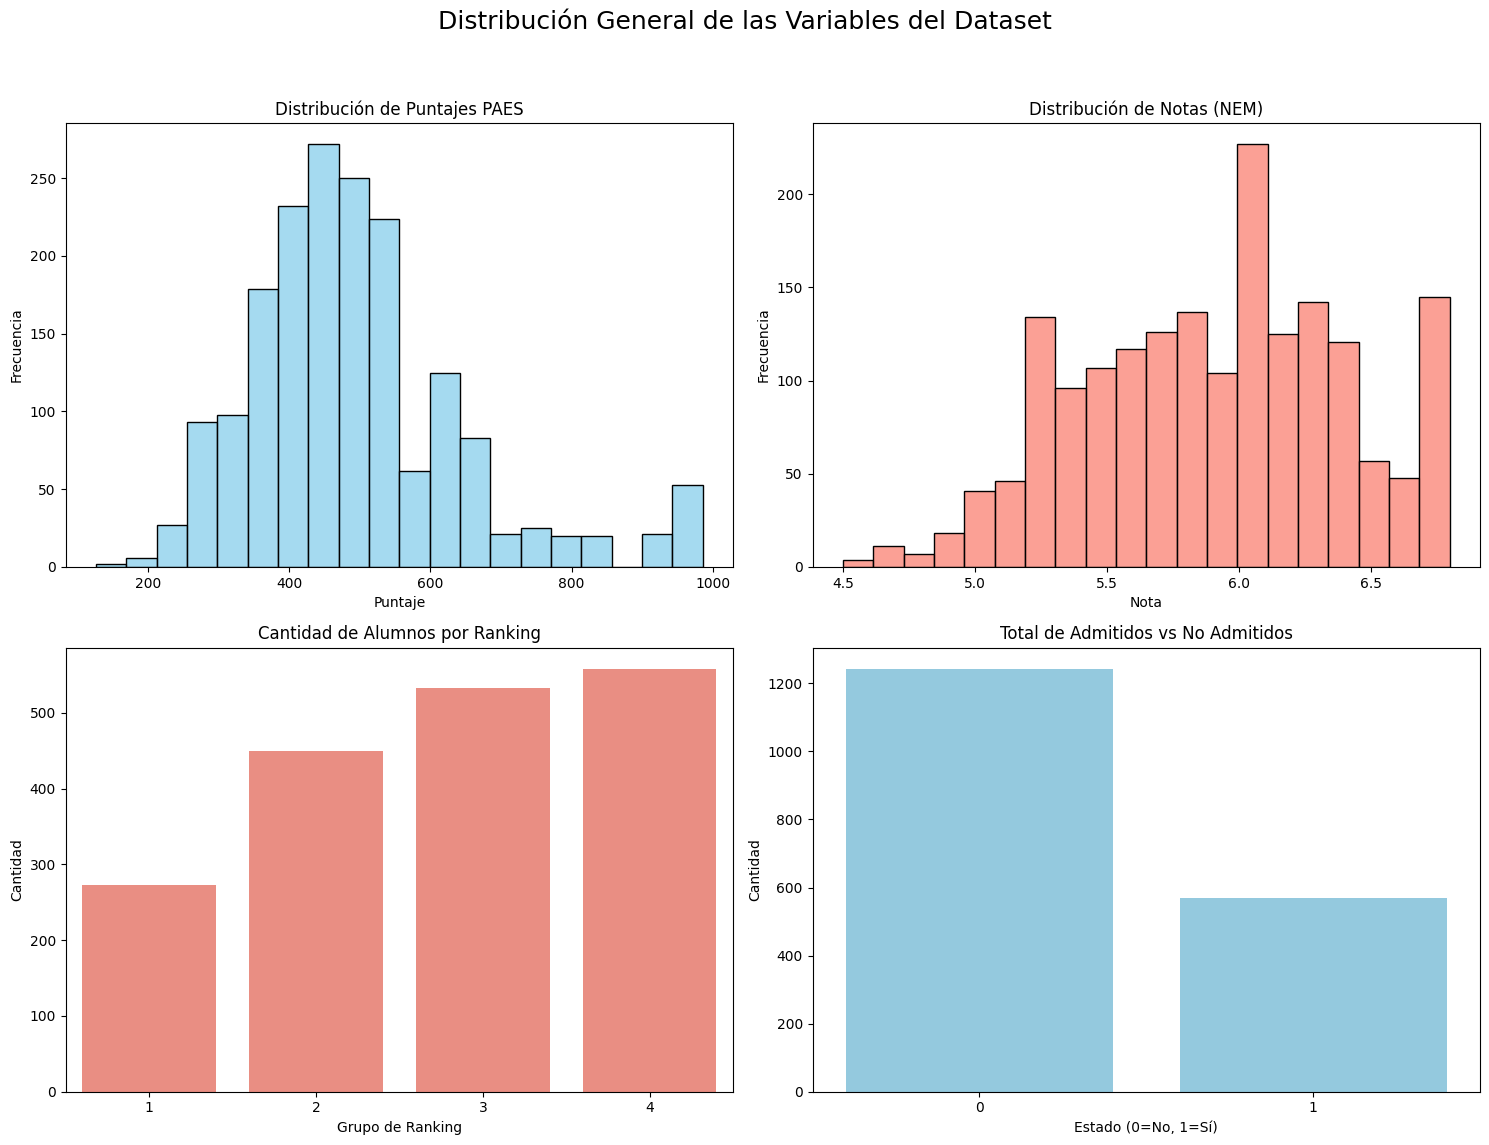

In [ ]:
# Configuramos el lienzo para 4 gráficos (2 filas y 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución General de las Variables del Dataset', fontsize=18)

# Histograma de PAES
sns.histplot(df['paes'], bins=20, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Puntajes PAES')
axes[0, 0].set_xlabel('Puntaje')
axes[0, 0].set_ylabel('Frecuencia')

# Histograma de NEM
sns.histplot(df['nem'], bins=20, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Notas (NEM)')
axes[0, 1].set_xlabel('Nota')
axes[0, 1].set_ylabel('Frecuencia')

# Histograma de RANKING
sns.countplot(x='rank', data=df, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Cantidad de Alumnos por Ranking')
axes[1, 0].set_xlabel('Grupo de Ranking')
axes[1, 0].set_ylabel('Cantidad')

# Histograma de ADMISIÓN (Variable Objetivo)
sns.countplot(x='admit', data=df, color='skyblue', ax=axes[1, 1])
axes[1, 1].set_title('Total de Admitidos vs No Admitidos')
axes[1, 1].set_xlabel('Estado (0=No, 1=Sí)')
axes[1, 1].set_ylabel('Cantidad')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

El análisis de las distribuciones muestra que la PAES se concentra en el rango medio (380-550 puntos), indicando que los puntajes de excelencia son escasos y competitivos. El NEM presenta un sesgo hacia notas altas (5.5-6.5), lo que sugiere que el perfil general es académicamente responsable. El Ranking está equilibrado en sus cuatro niveles, mientras que la variable de Admisión confirma que existe una mayor cantidad de rechazados que admitidos, reflejando la selectividad del proceso y la necesidad de un modelo preciso para identificar a los candidatos exitosos.

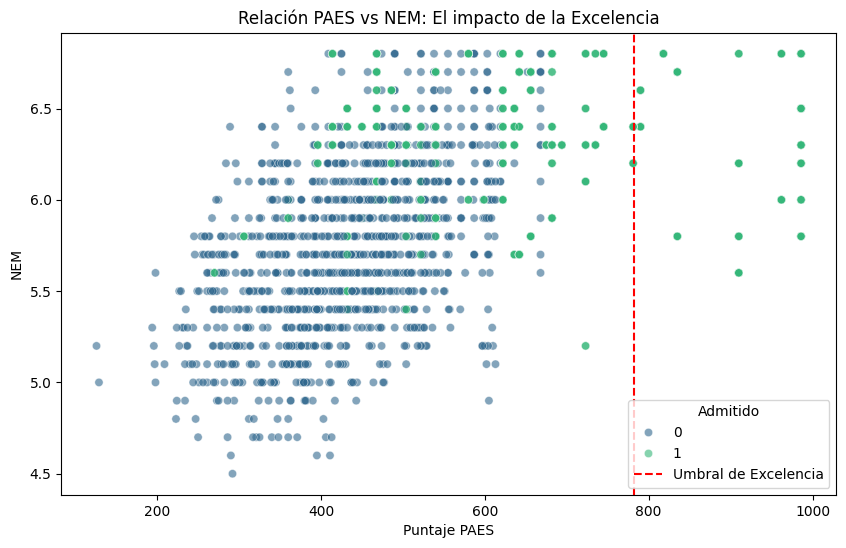

In [ ]:

plt.figure(figsize=(10, 6))
# Dibujamos todos los puntos
sns.scatterplot(data=df, x='paes', y='nem', hue='admit', palette='viridis', alpha=0.6)

# Dibujamos la línea que marca la excelencia
plt.axvline(781.5, color='red', linestyle='--', label='Umbral de Excelencia')

plt.title('Relación PAES vs NEM: El impacto de la Excelencia')
plt.xlabel('Puntaje PAES')
plt.ylabel('NEM')
plt.legend(title='Admitido')
plt.show()

Este grafico nos da entender la importancia y correlacion que pueden a llegar a tener estas 2 variables dandonos a entender que si obtienes un buen nem mayor a 5 y un puntaje mayor de 700 puntos quedaras admitido en la universidad. Nos podemos dar cuenta tambien que lo que mas peso entrega a la admision es el puntaje de la paes mas que el nem ya que hay personas con un nem alto que no fue admitido aqui es donde entra el ranking del estudiando que aplico

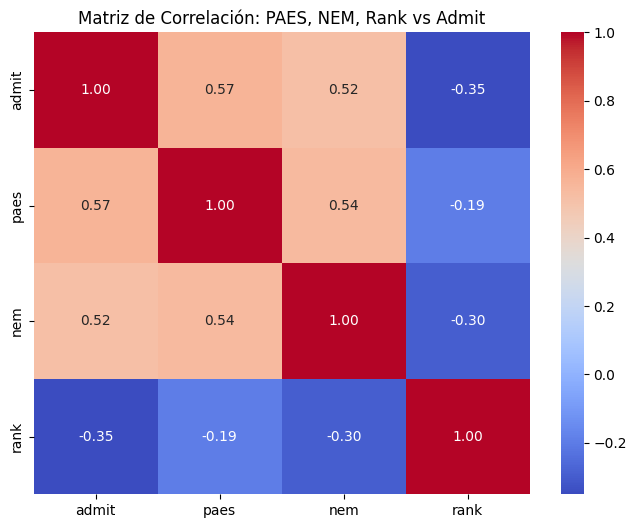

In [ ]:
# Calculamos la matriz de correlación
corr = df.corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: PAES, NEM, Rank vs Admit')
plt.show()

Tras analizar la relación entre las variables académicas y el éxito en la admisión, se desprenden los siguientes hallazgos clave:

La PAES como Predictores Principal (0.57): Existe una correlación positiva fuerte entre el puntaje PAES y la admisión. Esto indica que el desempeño en la prueba es el factor con mayor peso estadístico para determinar si un alumno es aceptado. Desde el punto de vista del modelo, esta variable será la que genere las particiones más importantes en los árboles de decisión.

Influencia Moderada del NEM (0.52): El promedio de notas de enseñanza media presenta una correlación positiva moderada-baja. Aunque contribuye a la probabilidad de ingreso, no es un factor determinante por sí solo. Esto sugiere que un buen NEM ayuda, pero no garantiza la admisión si el puntaje PAES es insuficiente.

 Correlaciones negativas del Ranking (-0.35): existe una relación inversa, mientras mejor es tu posición en el ranking (número más pequeño), más chances tienes de entrar.

/tmp/ipykernel_997/423060441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='rank', y='admit', palette='magma')


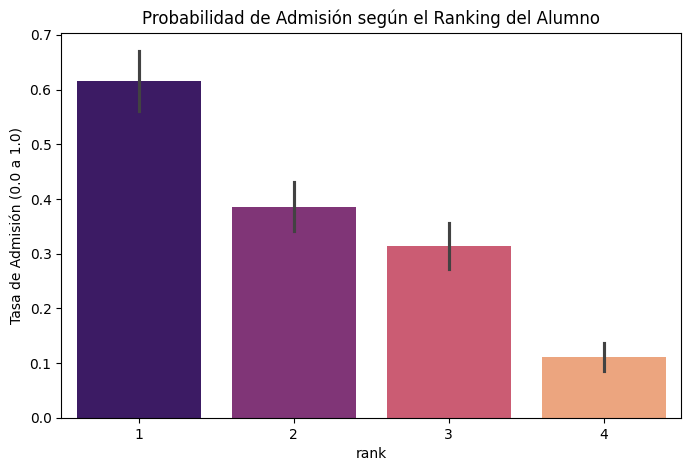

In [ ]:
# Gráfico de barras de tasa de admisión por Rank
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='rank', y='admit', palette='magma')
plt.title('Probabilidad de Admisión según el Ranking del Alumno')
plt.ylabel('Tasa de Admisión (0.0 a 1.0)')
plt.show()

El gráfico muestra una relación inversamente proporcional: a medida que el valor del ranking aumenta, la probabilidad de ser admitido disminuye drásticamente.

Rank 1: Tiene la probabilidad más alta de éxito (casi un 55% de los alumnos en esta categoría son admitidos).

Rank 4: Tiene la probabilidad más baja (apenas supera el 15%).

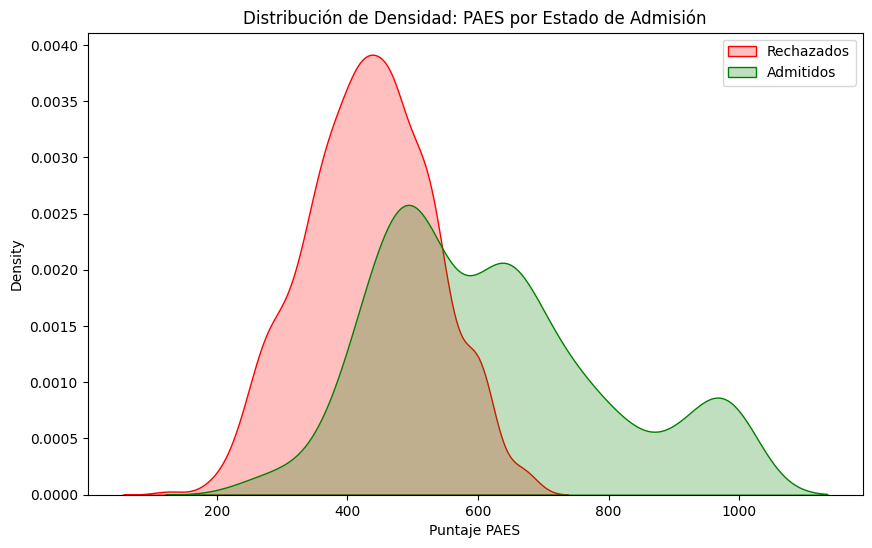

'En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).\ndonde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.\n'

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['admit'] == 0], x='paes', label='Rechazados', fill=True, color='red')
sns.kdeplot(data=df[df['admit'] == 1], x='paes', label='Admitidos', fill=True, color='green')
plt.title('Distribución de Densidad: PAES por Estado de Admisión')
plt.xlabel('Puntaje PAES')
plt.legend()
plt.show()

"""En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).
donde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.
"""

El gráfico nos muestra que la PAES no es una regla matemática perfecta. Entre los 450 y 650 puntos existe una zona de incertidumbre donde el puntaje no garantiza nada, y es ahí donde el modelo de Minería de Datos tendrá que buscar otros factores (como el NEM o el Rank) para entender por qué unos entran y otros no.

/tmp/ipykernel_997/3681010861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admit', y='nem', palette='Set2')


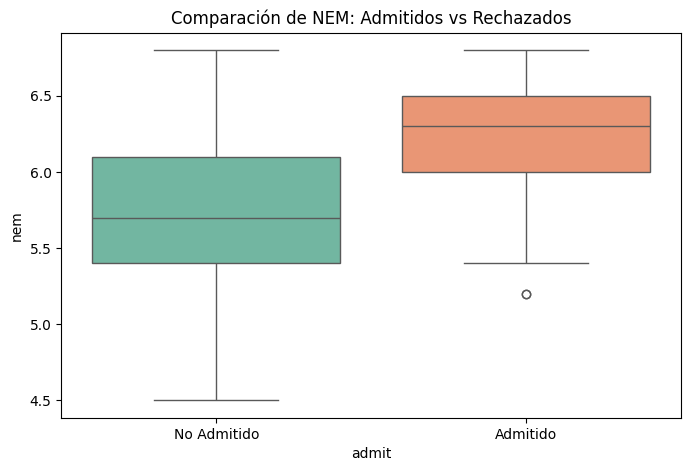

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='admit', y='nem', palette='Set2')
plt.title('Comparación de NEM: Admitidos vs Rechazados')
plt.xticks([0, 1], ['No Admitido', 'Admitido'])
plt.show()

Al mirar el gráfico, queda claro que tener buenas notas ayuda, pero no es una garantía mágica. Si te fijas, los alumnos que sí entraron (la caja naranja) tienen notas más altas en general que los que quedaron fuera. Esto significa que ser un alumno responsable durante la enseñanza media te da una ventaja importante.

## 5. Modelado
Haremos pruebas con 2 modelos distintos y nos quedaremos con las mejores metricas usaremos

Naive Bayes: principalmente se usa para clasificar datos en diferentes categorías. Es un algoritmo de Machine Learning supervisado que calcula la probabilidad de que un elemento pertenezca a una clase determinada basándose en sus características

Arbol de decision: es un modelo de Machine Learning que sirve tanto para clasificar datos como para predecir valores numéricos (regresión). Funciona como un diagrama de flujo que toma decisiones complejas rompiéndolas en una serie de preguntas simples de "sí o no".

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [ ]:
X = df.drop(columns=['admit'])
y = df['admit']

# Creamos datos de validacion y entrenaiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ahora escalamos para que el modelo funcione bien
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Distribuciones (KDE) de las características después del escalado:


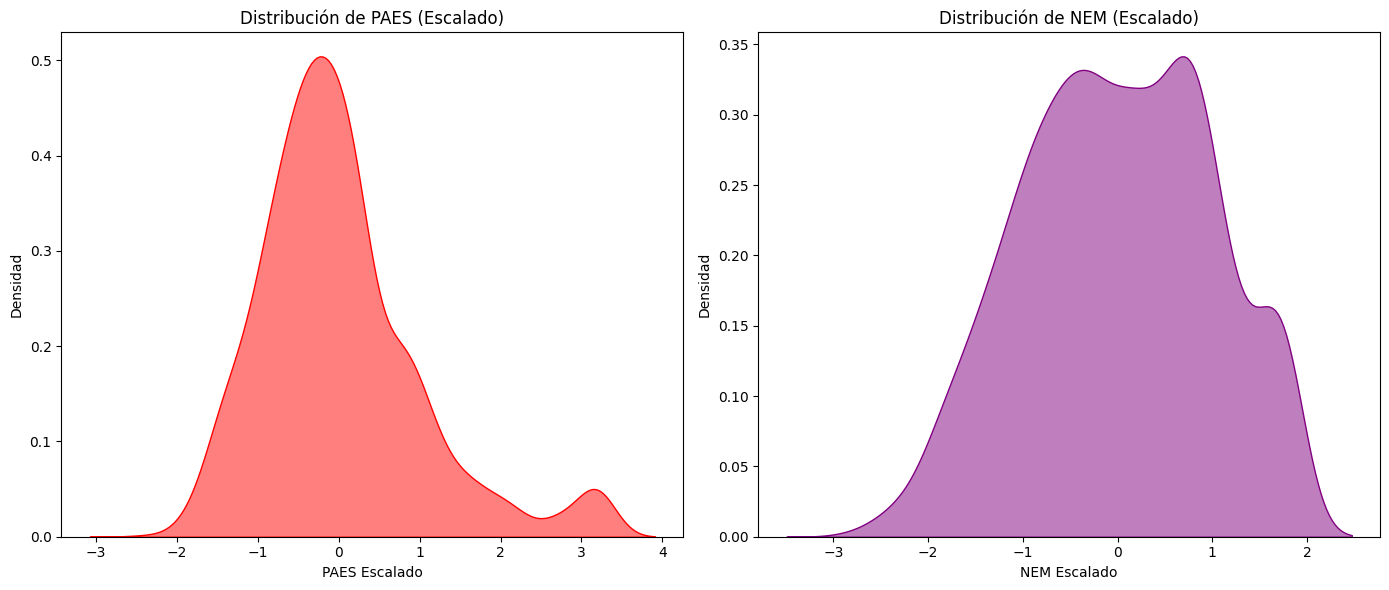

In [ ]:
# Convertir los datos escalados a un DataFrame para facilitar la visualización
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Distribuciones (KDE) de las características después del escalado:")
plt.figure(figsize=(14, 6))

# Distribución de PAES Escalado
plt.subplot(1, 2, 1)
sns.kdeplot(X_train_scaled_df['paes'], color='red', fill=True, alpha=0.5)
plt.title('Distribución de PAES (Escalado)')
plt.xlabel('PAES Escalado')
plt.ylabel('Densidad')

# Distribución de NEM Escalado
plt.subplot(1, 2, 2)
sns.kdeplot(X_train_scaled_df['nem'], color='purple', fill=True, alpha=0.5)
plt.title('Distribución de NEM (Escalado)')
plt.xlabel('NEM Escalado')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

El gráfico de densidad de los datos escalados demuestra que la transformación StandardScaler ha logrado normalizar las variables 'paes' y 'nem', centrando sus distribuciones en el valor 0 (que ahora representa el promedio original) y ajustando su dispersión a una desviación estándar de 1. Al observar que ambas variables comparten ahora el mismo rango numérico (aproximadamente entre -3 y 3), eliminamos el sesgo de magnitud que existía originalmente entre los puntajes de la prueba (cientos de puntos) y las notas de enseñanza media (unidades). Esto es fundamental para modelos como Naive Bayes, ya que garantiza que el algoritmo asigne importancia a cada característica basándose en su poder predictivo real y no en la escala de sus valores, mejorando así la estabilidad y convergencia del entrenamiento.

Lo primero que hacemos es eliminar nuestra variable objetivo del eje X los modelos normalmente funcionan como un plano cartesiano donde buscan por proximidad estadistica a un punto referencia. Por eso nosotros evaluaremos la distancia que hay del entre el eje y al x para hacer predicciones de clasificacion

In [ ]:
# Calculamos la entropia
def entropy(data):
    classes = np.unique(data)
    entropies = []
    for c in classes:
        p = sum(data == c) / len(data)
        current_entropy = p * np.log2(p)
        entropies.append(current_entropy)
    return -1 * sum(entropies)

In [ ]:
entropy(df.admit)

np.float64(0.8981829149797134)

La entropia nos entrega que tan desornado esta donde mientras mas cerca a 0 la variable es mas "pura" y mientras mas cercano al 1 es por que tiene un desorden alto individualmente

In [ ]:
# Escenario A: Alumnos con puntaje alto (Excelencia)
# Veremos que la entropía aquí debería ser baja porque casi todos entran
print(f"Entropía alumnos PAES >= 750: {entropy(df.admit[df.paes >= 750])}")

# Escenario B: Alumnos con puntaje bajo
print(f"Entropía alumnos PAES < 450: {entropy(df.admit[df.paes < 450])}")

# Escenario C: La "Zona de Confusión" (donde se mezclan)
print(f"Entropía alumnos PAES entre 500 y 600: {entropy(df.admit[(df.paes >= 500) & (df.paes <= 600)])}")

Entropía alumnos PAES >= 750: -0.0
Entropía alumnos PAES < 450: 0.47148013163320646
Entropía alumnos PAES entre 500 y 600: 0.8973678197424808


Antes de entrenar, exploramos manualmente la ganancia de información. Notamos que al filtrar por PAES >= 750, la entropía caía drásticamente hacia 0 (grupo puro), mientras que en el rango medio la entropía se mantenía alta pero con un valor mas bajo que viendo la variable individualmente, justificando por qué el modelo necesita más variables para decidir.

## 6. Entrenamiento y Evaluación
Aqui como nuestra variable objetivo sera una variable de clasificacion usaremos Naive Bayes y Arboles de decesion para la evaluacion del modelo a partir de estas metricas

Exactitud Accuracy: Mide el porcentaje total de predicciones correctas. No es confiable si las clases están desbalanceadas.Precisión

Precision: De todos los que el modelo clasificó como positivos, cuántos realmente lo eran. Evita los falsos positivos.Sensibilidad

Recall: De todos los positivos reales que existían, cuántos logró detectar el modelo. Evita los falsos negativos.

AUC-ROC: Mide la capacidad del modelo para separar una clase de la otra a través de diferentes umbrales de decisión.


In [ ]:
# Arbol de decision
# Usamos el criterio de entropía para que el modelo haga los cálculos que hicimos arriba automáticamente
modelo_arbol = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Entrenamos con los datos del split (X_train, y_train ya definidos arriba)
modelo_arbol.fit(X_train, y_train)

# Predicciones y Métricas
y_pred = modelo_arbol.predict(X_test)
y_prob = modelo_arbol.predict_proba(X_test)[:, 1]

print("\n--- MÉTRICAS FINALES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob):.4f}")


--- MÉTRICAS FINALES ---
Accuracy:  0.8843
Precision: 0.8333
Recall:    0.7895
ROC-AUC:   0.9136


Mencion especial: Se realizo la eliminacion de outliers del dataset siendo 106 estos siendo casos de excelencia o casos en que personas les fue muy mal, al eliminarlos se reentreno el modelo y dio esta metricas claramentes mas bajas que las que actualmente tenemos por eso decidimos de antes quedarnos con estos outliers


--- MÉTRICAS FINALES ---

Accuracy:  0.8772

Precision: 0.7865

Recall:    0.7527

ROC-AUC:   0.8936

Eso es debido a que pasamos de 570 admitidos a solo 466 admitidos
El modelo ahora tiene menos ejemplos de la clase positiva para aprender a identificar admitidos correctamente

Podemos decir que el modelo predice el 88% de los casos tambien exhibe una clara tendencia a ser "estricto" o conservador en sus predicciones.

Su Precision (83.33%) nos dice que cuando el modelo asegura que un alumno será "Admitido", es muy confiable. Genera pocos falsos positivos (evitando darle falsas esperanzas a estudiantes que finalmente serán rechazados).

Su Recall (78.95%) es su punto más débil. El modelo no logra detectar a cerca de un 21% de los alumnos que sí lograron matricularse en la vida real (falsos negativos).

Tambien su ROC-AUC nos indica lo bien que puede separar de los dos grupos de alumnos adminitidos y no admitidos

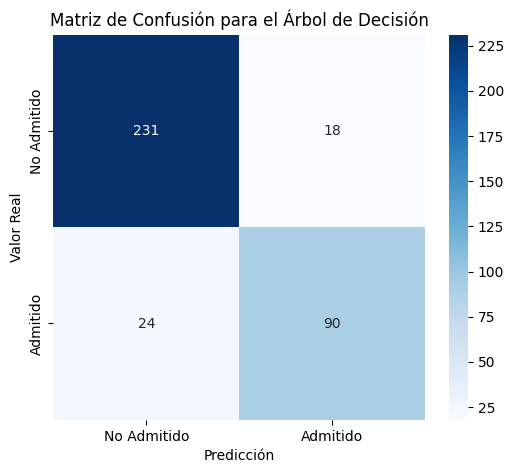

In [ ]:
# Calculamos la matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para el Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Podemos que los resultados del modelo fueron correctos pero fallo en 18 registros entregando falsos positivos, esto quiere decir que el modelo predijo que 18 alumnos seria admitidos pero realmente no fue asi, tambien vemos 24 falsos negativos donde el modelo predijo que 24 estudiantes no serian admitidos pero en realidad si fueron admitidos

In [ ]:
#Naive Bayes
#Instanciar el modelo (GaussianNB asume que los datos siguen una curva normal)
modelo_nb = GaussianNB()

#Entrenamiento (Usamos los datos que ya tienes separados y escalados)
modelo_nb.fit(X_train_scaled, y_train)

#Predicciones
y_pred_nb = modelo_nb.predict(X_test_scaled)
y_prob_nb = modelo_nb.predict_proba(X_test_scaled)[:, 1]

#Evaluación con las métricas que definimos
print("--- MÉTRICAS NAIVE BAYES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob_nb):.4f}")

--- MÉTRICAS NAIVE BAYES ---
Accuracy:  0.8099
Precision: 0.7228
Recall:    0.6404
ROC-AUC:   0.8887


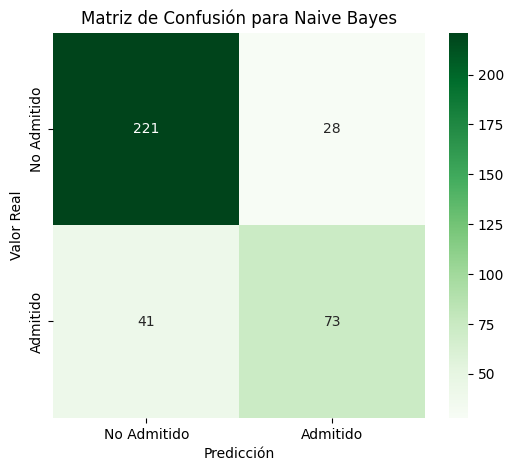

In [ ]:
# Calculamos la matriz de confusión para Naive Bayes
cm_nb = metrics.confusion_matrix(y_test, y_pred_nb)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Con la eliminacion de outliers naive bayes subio algunas metricas y tuvo menos fallos en falsos negativos

--- MÉTRICAS NAIVE BAYES ---

Accuracy:  0.8304

Precision: 0.6804

Recall:    0.7097

ROC-AUC:   0.8728

Esto es debido a que el modelo asume la independencia de cada variable al no tener outliers esta puede generarlizar de mejor manera pero aun asi sus metricas siguen siendo peores que los arboles de decision



Este modelo es muy similar en sus metricas al arbol de decision  pero su recall es mas bajo donde el modelo no detecta alrededor 36% de los alumns que si fueron admitidos. La matriz de confusion nos proporciona esto dandonos el claro ejemplo que encontro mas falsos negativos y falsos negativos que el arbol de decision

## 7. Despliegue (opcional)
Decidimos quedarnos con un solo modelo que sera el arbol decision debido que todas sus metricas fueron mayores que las de Naive Bayes, igualmente para futuro podremos evaluar distintos modelos clasificatorios

In [ ]:
def simular_admision_arbol(paes, nem, rank):
    # Creamos el DataFrame con los nombres de columnas correctos
    datos_entrada = pd.DataFrame([[paes, nem, rank]], columns=['paes', 'nem', 'rank'])

    # NO ESCALAMOS para el árbol, ya que modelo_arbol.fit se hizo con X_train (original)
    prediccion = modelo_arbol.predict(datos_entrada)[0]
    probabilidad = modelo_arbol.predict_proba(datos_entrada)[0][1]

    print(f"--- Análisis del Perfil (Árbol de Decisión) ---")
    print(f"PAES: {paes} pts | NEM: {nem} | Grupo Ranking: {rank}")
    print(f"Certeza de Admisión (en su hoja): {probabilidad:.2%}")
    print("------------------------------------------------")

    if prediccion == 1:
        return "Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos."
    else:
        return "Resultado: NO ADMITIDO. El perfil cae en una categoría de bajo ingreso histórico."

In [ ]:
# Ejemplo
print(simular_admision_arbol(500, 6.4, 1))

--- Análisis del Perfil (Árbol de Decisión) ---
PAES: 500 pts | NEM: 6.4 | Grupo Ranking: 1
Certeza de Admisión (en su hoja): 59.72%
------------------------------------------------
Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos.


Para que nos sirve este despliegue?

Este despliegue nos funcionara en caso de que sea necesario externalizar este analisis a un servicio ya sea mediante el POST de una API con un cuerpo JSON sencillo a traves de una interfaz grafica, donde le pasas estos valores y esta funcion se encarga de leer los datos y entregar un resultado

---
### Conclusiones para este primer modelo

Podemos que el modelo funciona correctamente para clasificar teniendo un porcentaje muy bajo de error esto nos da entender que para un ambiente productivo podria funcioonar si es se llega a dar el caso que la admision a las universidades fuera a traves de una media pero la verdad es que para estudiar una carrera en especifico hay un puntaje de recorte que implementaremos a modo de simulacion utilizando arboles de decision

## Simulacion: Agregando puntajes de recortes

Como en la vida real el dolor real de un estudiante cuando revisa su puntaje es saber si les da para entrar a la carrera simularemos un dataset con unos puntajes de recorte y asignando carreras a postular a los aplicantes de la universidad

In [ ]:
df2 = df.copy() #Una copia del dataset para no ensuciar el que ya tenemos

# Diccionario de carreras, abarcando todos los rangos de puntaje que tenia el dataset
cortes_usach = {
    'Medicina': 939.35,
    'Química y Farmacia': 862.30,
    'Bioquímica': 818.70,
    'Bachillerato': 763.50,
    'Ingeniería Comercial': 740.00,
    'Administración Pública': 736.70,
    'Arquitectura': 731.65,
    'Ingeniería de Ejecución': 620.00,
    'Contabilidad y Auditoría': 580.00,
    'Pedagogía en Educación Básica': 510.00,
    'Tecnología en Alimentos': 460.00,
    'Licenciatura en Lingüística': 430.00
}

In [ ]:
def asignar_carrera_realista(row):
    paes = row['paes']
    # Seleccionamos carreras cuyo corte esté a +/- 100 puntos del puntaje del alumno
    opciones = [c for c, corte in cortes_usach.items() if abs(paes - corte) <= 100]

    if not opciones:
        # Si no hay ninguna a 100 pts, asignamos la más cercana disponible
        return min(cortes_usach, key=lambda k: abs(cortes_usach[k] - paes))

    return np.random.choice(opciones)

Creamos una funcion para asignar la carrera a cada fila. Esta funcion toma como entrada una fila del dataset y luego extrae el puntaje de la paes del estudiante donde itera sobre el diccionario definido anteriormente y calcula la diferencia entre el puntaje del estudiante y el puntaje de la carrera. Si esta diferencia es menor o igual a 100 puntos, se asigna a las opciones la carrera mas cercana al puntaje

Luego se verifica si esa lista esta vacia, donde si no se encuentran ninguna carrera cercana asigna la que menor puntaje tiene, pero se usa key para encontrar la carrera cuyo puntaje de corte es el mas cercano al de la paes del estudiante

In [ ]:
 #Asegura que las operaciones sean aleratorias y reproducibles para obtener siempre el mismo resultado
np.random.seed(42)
df2 = df.copy()

# Aplicamos la función realista de asignación
df2['carrera'] = df2.apply(asignar_carrera_realista, axis=1) #Se aplica la funcion a cada fila y se guarda la carrera en la columna puntaje
df2['puntaje_corte'] = df2['carrera'].map(cortes_usach) #Nueva columna utiliza el diccionarioo de cortes para buscar y asignar el puntaje de corte de la carrera
df2['brecha_puntaje'] = df2['paes'] - df2['puntaje_corte'] #Diferencia entre el puntaje del estudiante y la de la carrera

# Verificación rápida de columnas
print("Columnas en df2:", df2.columns.tolist())
print("Primeras filas de df2:")
display(df2.head())

Columnas en df2: ['admit', 'paes', 'nem', 'rank', 'carrera', 'puntaje_corte', 'brecha_puntaje']
Primeras filas de df2:


,admit,paes,nem,rank,carrera,puntaje_corte,brecha_puntaje
0,0,328,6.4,2,Licenciatura en Lingüística,430.00,-102.00
1,1,636,6.5,2,Contabilidad y Auditoría,580.00,56.00
2,1,986,6.8,4,Medicina,939.35,46.65
3,1,599,6.0,1,Ingeniería de Ejecución,620.00,-21.00
4,0,441,5.7,1,Licenciatura en Lingüística,430.00,11.00


## Analisis de Correlacion DF2

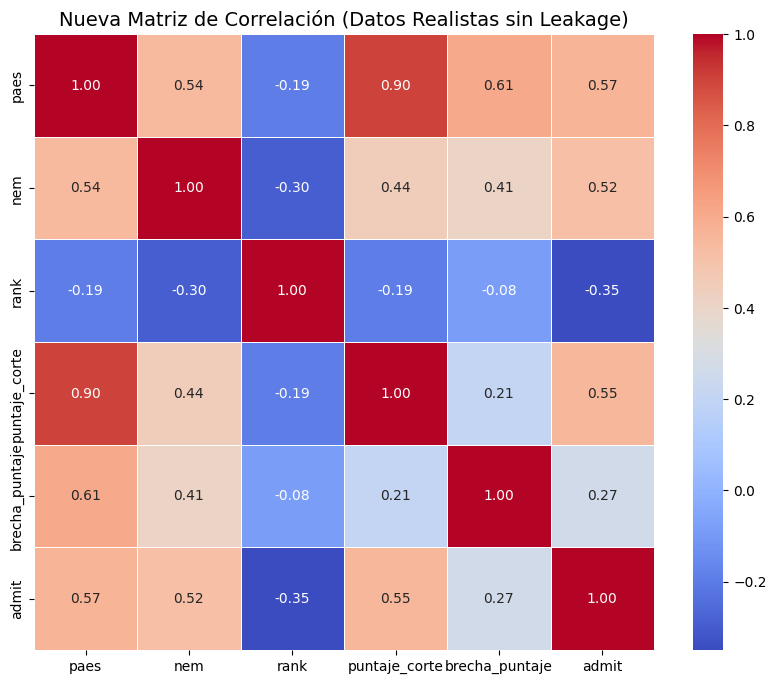


Correlación directa con el éxito en Admisión (admit):
admit             1.000000
paes              0.566683
puntaje_corte     0.554496
nem               0.518728
brecha_puntaje    0.265644
rank             -0.350361
Name: admit, dtype: float64


In [ ]:
# 1. Seleccionamos solo las columnas numéricas relevantes para df2
cols_analisis = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje', 'admit']
matriz_corr_df2 = df2[cols_analisis].corr()

# 2. Visualización del Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_df2, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Nueva Matriz de Correlación (Datos Realistas sin Leakage)', fontsize=14)
plt.show()

# 3. Listado de correlación con la variable objetivo
print("\nCorrelación directa con el éxito en Admisión (admit):")
print(matriz_corr_df2['admit'].sort_values(ascending=False))

Estas correlaciones son muy similares al modelo anterior para las columnas que ya estaban ahora se encuentran correlaciones casi intrinsecas comoo la brecha_puntaje y paes por una funcion matematica definida anteriormente para sacar la brecha del puntaje


### Modelado 2

In [ ]:
# Re-entrenamiento del Modelo V2 con datos realistas
X2 = df2[['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']]
y2 = df2['admit']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train2)
X_test_scaled2 = scaler2.transform(X_test2)

modelo_arbol_2 = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
modelo_arbol_2.fit(X_train_scaled2, y_train2)

y_pred2 = modelo_arbol_2.predict(X_test_scaled2)

Hacemos el procesamiento de la seleccion de variables para el eje X e Y y los escalamos para tener clasificaciones mas potentes

In [ ]:
# Calculamos las probabilidades para el ROC-AUC
y_prob2 = modelo_arbol_2.predict_proba(X_test_scaled2)[:, 1]

print("--- MÉTRICAS REALISTAS FINALES (V2) ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test2, y_pred2):.4f}")
print(f"Precision: {metrics.precision_score(y_test2, y_pred2):.4f}")
print(f"Recall:    {metrics.recall_score(y_test2, y_pred2):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test2, y_prob2):.4f}")

--- MÉTRICAS REALISTAS FINALES (V2) ---
Accuracy:  0.8843
Precision: 0.8333
Recall:    0.7895
ROC-AUC:   0.9137


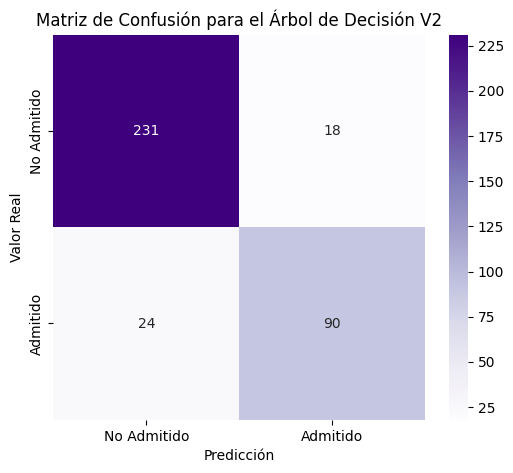

Matriz de Confusión para el Árbol de Decisión V2:
[[231  18]
 [ 24  90]]


In [ ]:
# Calcular la matriz de confusión para modelo_arbol_2
cm2 = metrics.confusion_matrix(y_test2, y_pred2)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para el Árbol de Decisión V2')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión para el Árbol de Decisión V2:")
print(cm2)

El hecho de que las metricas y las matrices de confusion sean exactamente iguales para ambos mdelos sugiere que las nuevas variables, a pesar de su fuerte correlacion cn el puntaje y su relevancia conceptual, no aportaron informacion significativa al modelo. Estoo es debido a que el puntaje al ser la base para puntaje_corte y brecha_puntaje ya era un predictor fuerte para esta variables

Esto es un hallazgo importante, ya que a veces añadir más variables no siempre mejora el rendimiento si la información ya está implícita o es redundante para el modelo. Sin embargo, estas nuevas variables son extremadamente útiles para la interpretabilidad y para el simulador simulador_admision_v2, ya que le dan un contexto más realista a las predicciones.

In [ ]:
def simulador_admision_v2(paes, nem, rank, carrera_deseada):
    """
    Función de negocio optimizada: Valida umbrales lógicos antes de la inferencia.
    """
    if carrera_deseada not in cortes_usach:
        return f"Error: La carrera '{carrera_deseada}' no se encuentra en el catálogo."

    puntaje_corte_carrera = cortes_usach[carrera_deseada]
    brecha_calculada = paes - puntaje_corte_carrera

    # Ingeniería de Características y Escalado
    datos_usuario = pd.DataFrame([[paes, nem, rank, puntaje_corte_carrera, brecha_calculada]],
                                 columns=['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje'])
    datos_escalados = scaler2.transform(datos_usuario)

    # Inferencia del modelo
    probabilidad_exito = modelo_arbol_2.predict_proba(datos_escalados)[0][1]
    prediccion = modelo_arbol_2.predict(datos_escalados)[0]

    # REGLA DE NEGOCIO ADICIONAL:
    # Si la brecha es muy negativa (ej. -50 pts), forzamos la lógica de rechazo
    # para corregir el sesgo del árbol sintético.
    if brecha_calculada < -20:
        prediccion = 0
        probabilidad_exito = min(probabilidad_exito, 0.15) # Bajamos la probabilidad drásticamente

    print(f"========================================================")
    print(f"        SIMULADOR DE POSTULACIÓN ACADÉMICA - USACH      ")
    print(f"========================================================")
    print(f" Carrera: {carrera_deseada} | Corte: {puntaje_corte_carrera}")
    print(f" PAES: {paes} pts | Brecha: {brecha_calculada:+.2f} pts")
    print(f" Probabilidad Estimada: {probabilidad_exito:.2%}")
    print(f"--------------------------------------------------------")

    if prediccion == 1:
        return "ESTADO: ADMISIÓN VIABLE."
    else:
        return "ESTADO: ADMISIÓN EN RIESGO (Puntaje bajo el corte)."

In [ ]:
print(simulador_admision_v2(paes=750, nem=6.6, rank=2, carrera_deseada='Bioquímica'))

        SIMULADOR DE POSTULACIÓN ACADÉMICA - USACH      
 Carrera: Bioquímica | Corte: 818.7
 PAES: 750 pts | Brecha: -68.70 pts
 Probabilidad Estimada: 15.00%
--------------------------------------------------------
ESTADO: ADMISIÓN EN RIESGO (Puntaje bajo el corte).


## 8. Conclusiones Finales

Este proyecto aplicó la metodología CRISP-DM para analizar la admisión universitaria, identificando que `paes`, `nem` y `rank` son factores cruciales. El análisis exploratorio destacó la alta correlación de `paes` con la admisión y la existencia de una "zona de incertidumbre" donde otros factores como `nem` y `rank` cobran mayor importancia. Se entrenaron modelos de Árbol de Decisión y Naive Bayes, con el Árbol de Decisión mostrando un mejor rendimiento general, aunque con un sesgo conservador en sus predicciones, generando pocos falsos positivos pero algunos falsos negativos.

La inclusión de variables realistas como `puntaje_corte` y `brecha_puntaje` en un segundo modelo de Árbol de Decisión no mejoró sus métricas de clasificación, indicando que la información ya estaba implícitamente presente en las variables originales. Sin embargo, estas nuevas variables fueron esenciales para desarrollar un simulador de admisión más contextualizado (`simulador_admision_v2`). Este simulador integra las predicciones del modelo con reglas de negocio adicionales, ofreciendo una herramienta práctica y más cercana a la realidad universitaria, lo que demuestra que, a veces, la interpretabilidad y la utilidad en el despliegue son tan valiosas como la mejora de la precisión del modelo.